# V2 Pipeline - Phase 1: Phân tích Khám phá Dữ liệu (EDA) & Kỹ thuật Đặc trưng (Dữ liệu MIMIC)

Thực hiện theo chỉ đạo chuyên môn trên bộ dữ liệu **MIMIC**:
1. **Kiểm tra thuộc tính phân loại**: Rà soát & One-Hot Encoding cho các cột phân loại (nếu có).
2. **Khảo sát độ biến thiên (Variance Analysis)**: Thống kê độ lệch chuẩn & độ biến thiên của các đặc trưng thô khi chưa chuẩn hóa.
3. **Xử lý Khuyết thiếu & Nhiễu**: Áp dụng Mean Imputation (`SimpleImputer(strategy='mean')`).
4. **Tạo 2 Bộ Đặc trưng Scaled V2 cho MIMIC**: So sánh **Min-Max Scaling** (về `[0, 1]`) vs **Z-Score Normalization**.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')

print('✅ Nạp thành công các thư viện EDA & Preprocessing V2 cho dữ liệu MIMIC!')


✅ Nạp thành công các thư viện EDA & Preprocessing V2 cho dữ liệu MIMIC!


### 1. Nạp Dữ Liệu Thô MIMIC & Kiểm tra Biến Phân Loại (Categorical Features Check)

In [2]:
data_candidates = [
    '../../data/features/mimic_train_features_advanced.csv',
    '../../data/features/mimic_train_features.csv',
    'data/features/mimic_train_features_advanced.csv',
    'data/features/mimic_train_features.csv'
]
data_path = next((p for p in data_candidates if os.path.exists(p)), None)

df_raw = pd.read_csv(data_path)
print(f"Nạp thành công dữ liệu MIMIC từ: {data_path}")
print(f"Kích thước dữ liệu thô MIMIC: {df_raw.shape[0]} mẫu | {df_raw.shape[1]} cột")

# Kiểm tra các cột dạng thuộc tính (Categorical/Object)
cat_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Các cột thuộc tính phân loại (Categorical): {cat_cols}")

if cat_cols:
    df_processed = pd.get_dummies(df_raw, columns=cat_cols, drop_first=True)
    print(f"✅ Đã áp dụng One-Hot Encoding cho các biến phân loại!")
else:
    df_processed = df_raw.copy()
    print("ℹ️ Tất cả các đặc trưng MIMIC đều là dạng số (Numerical Features).")


Nạp thành công dữ liệu MIMIC từ: ../../data/features/mimic_train_features_advanced.csv
Kích thước dữ liệu thô MIMIC: 1202 mẫu | 17 cột
Các cột thuộc tính phân loại (Categorical): []
ℹ️ Tất cả các đặc trưng MIMIC đều là dạng số (Numerical Features).


### 2. Kiểm tra Độ Biến Thiên của Dữ Liệu Thô MIMIC (Variance & Std Dev Analysis)

In [3]:
feature_cols = [c for c in df_processed.columns if c != 'status']
X_raw = df_processed[feature_cols]
y = df_processed['status']

stats_df = pd.DataFrame({
    'Mean': X_raw.mean(),
    'Std_Dev': X_raw.std(),
    'Variance': X_raw.var(),
    'Min': X_raw.min(),
    'Max': X_raw.max(),
    'Range': X_raw.max() - X_raw.min()
}).sort_values(by='Variance', ascending=False)

print("--- BẢNG THỐNG KÊ ĐỘ BIẾN THIÊN CÁC ĐẶC TRƯNG THÔ MIMIC (LÚC CHƯA CHUẨN HÓA) ---\n")
print(stats_df.round(4).to_string())


--- BẢNG THỐNG KÊ ĐỘ BIẾN THIÊN CÁC ĐẶC TRƯNG THÔ MIMIC (LÚC CHƯA CHUẨN HÓA) ---

                 Mean   Std_Dev    Variance       Min        Max     Range
Mean_NN      722.5807  167.3750  28014.3870  456.1231  1255.6522  799.5291
RMSSD        151.6692  114.4291  13094.0129    6.2470   691.7986  685.5516
SD2          113.1738   87.3974   7638.3025    3.6730   542.6469  538.9738
SDNN         112.8932   84.4066   7124.4702    4.2922   520.0803  515.7882
SD1          107.1919   80.8791   6541.4333    4.4151   488.4410  484.0259
pNN50         47.9080   33.0965   1095.3802    0.0000   100.0000  100.0000
LF_norm       30.4046   19.1046    364.9842    0.1121    93.7846   93.6725
HF_norm       69.5954   19.1046    364.9842    6.2154    99.8879   93.6725
HR_mean       87.2400   18.8515    355.3774   47.7839   131.5434   83.7595
NN50          19.5624   14.4130    207.7351    0.0000    47.0000   47.0000
CV            16.2910   11.9669    143.2077    0.8004    58.9153   58.1149
LF_HF_Ratio    0.6

### 3. Xử lý Missing Values (Mean Imputation) & Chuẩn hóa Dữ liệu (Min-Max vs Z-Score)

In [4]:
# 1. Mean Imputation (Xử lý nhiễu & giá trị khuyết theo khuyến nghị)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_raw)
X_imputed_df = pd.DataFrame(X_imputed, columns=feature_cols)

# 2. Min-Max Scaling [0, 1]
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X_imputed_df)
df_minmax = pd.DataFrame(X_minmax, columns=feature_cols)
df_minmax['status'] = y.values

# 3. Z-Score Normalization (StandardScaler)
zscore_scaler = StandardScaler()
X_zscore = zscore_scaler.fit_transform(X_imputed_df)
df_zscore = pd.DataFrame(X_zscore, columns=feature_cols)
df_zscore['status'] = y.values

# Lưu trữ 2 bộ dữ liệu V2 cho MIMIC
save_dir_candidates = ['../../data/features', 'data/features']
save_dir = next((d for d in save_dir_candidates if os.path.exists(os.path.dirname(d))), '../../data/features')
os.makedirs(save_dir, exist_ok=True)

path_minmax = os.path.join(save_dir, 'v2_mimic_minmax_scaled.csv')
path_zscore = os.path.join(save_dir, 'v2_mimic_zscore_scaled.csv')

df_minmax.to_csv(path_minmax, index=False)
df_zscore.to_csv(path_zscore, index=False)

print(f"✅ Đã lưu tập Min-Max Scaled MIMIC V2 vào: {path_minmax}")
print(f"✅ Đã lưu tập Z-Score Scaled MIMIC V2 vào: {path_zscore}")


✅ Đã lưu tập Min-Max Scaled MIMIC V2 vào: ../../data/features\v2_mimic_minmax_scaled.csv
✅ Đã lưu tập Z-Score Scaled MIMIC V2 vào: ../../data/features\v2_mimic_zscore_scaled.csv


### 4. Trực quan hóa So sánh Phân phối MIMIC: Thô vs Min-Max vs Z-Score

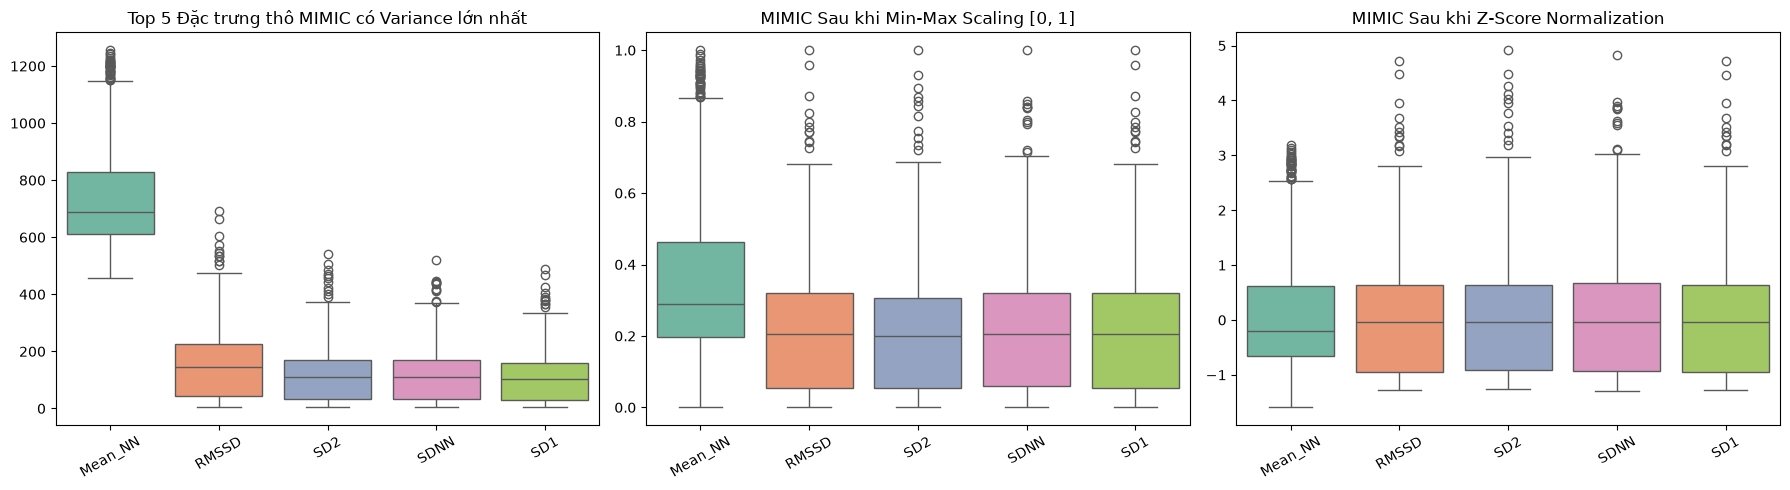

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_5_var_cols = stats_df.index[:5].tolist()

sns.boxplot(data=X_raw[top_5_var_cols], ax=axes[0], palette='Set2')
axes[0].set_title('Top 5 Đặc trưng thô MIMIC có Variance lớn nhất')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_minmax[top_5_var_cols], ax=axes[1], palette='Set2')
axes[1].set_title('MIMIC Sau khi Min-Max Scaling [0, 1]')
axes[1].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_zscore[top_5_var_cols], ax=axes[2], palette='Set2')
axes[2].set_title('MIMIC Sau khi Z-Score Normalization')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
